# Building a Recipe Retriever 

## What is LangGraph?

When you call an LLM (like ChatGPT or Llama), you send one prompt and get one response back. That works fine for simple questions, but what if you want the AI to **do multiple steps** — like a human would?

For example, creating a dish involves several steps:
1. First, identify what youre in the mood to eat, and what ingredients you have)
2. Then, create a what information you need ( ingredients , how to make , for how many people etc)
3. Then, check if the recipe that is retrieved is doable/relevant/something you like based of your preferences etc
4. Finally, improve the plan based on that feedback

**LangGraph** lets you build exactly this: a **graph of steps** (called *nodes*) connected by **edges**, where each node can call an LLM, run Python code, or both. A shared **state** flows through the graph so each step can read what the previous steps produced.

Think of it like an assembly line in a factory:

```
  [Raw materials]  →  [Station 1: Cut]  →  [Station 2: Assemble]  →  [Station 3: Inspect]  →  [Finished product]
```

The "raw material" is the user's input. Each station (node) does one job and passes its result to the next station via a shared conveyor belt (the state). LangGraph is the system that controls which station runs when.

## The three building blocks

| Concept | What it is | In our trip planner |
|---------|-----------|--------------------|
| **State** | A shared dictionary that every node can read from and write to | Contains the ingredients, number of items, duration, etc. |
| **Nodes** | Python functions that do one step of work (often by calling an LLM) | `create_recipe`, `evaluate_recipe` |
| **Edges** | Arrows that define the order in which nodes execute | analyze → generate → end |

In this notebook I will attempt to build a recipe retriever.


### Part 1 — Setup

We use models hosted by **Groq** (https://groq.com/), which provides free access to open-source LLMs with very low latency. Groq is also GDPR-compliant, making it suitable for educational use in Europe.

In [1]:
# !pip install langgraph -U
# !pip install langchain -U
# !pip install langchain_groq -U

In [2]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os
os.environ['GROQ_API_KEY'] = "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"

# Load the api keys stored in the .env file
load_dotenv(".env", override=True)

# Load the model
llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0.3)
llmReasoning = ChatGroq(model_name="qwen/qwen3-32b", temperature=0.3)

Next, we will define a **Pydantic class** and the **AgentState**.

The Pydantic class is used to describe the structured output we expect from the language model. Instead of receiving free-form text, we explicitly define the fields (such as a cleaned question and key dimensions), which makes the output easier to validate, inspect, and reuse across different nodes.

The AgentState defines the shared state that flows through the LangGraph. It describes what information is available at each step of the graph and how intermediate results (like the question analysis or final answer) are passed from one node to the next.

## Part 2 — Defining State and Structured Outputs

Before we can build the graph, we need to define **what data flows through it**. This is the **State**.

Imagine the state as a shared notebook that every team member (node) can read and write in. When the first node finishes its work, it writes its results in the notebook. The next node picks up the notebook, reads what's there, does its own work, and adds its results.

We also use **Pydantic classes** to define the *shape* of each node's output. Instead of getting free-form text from the LLM, we force it to return structured JSON with specific fields. This makes the output predictable and easy to use in the next step.

### Why structured output matters

Without structured output, the LLM might return something like:
```
"Barcelona has a Mediterranean climate and is known for architecture and beaches."
```

With structured output, we get:
```json
{
  "climate": "Mediterranean — warm summers, mild winters",
  "best_known_for": ["architecture", "beaches", "food culture"],
  "travel_tips": ["book Sagrada Familia tickets in advance"]
}
```
The second version is much easier for the next node to work with!

In [3]:
from typing import TypedDict, List, Literal
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

# -------------------------
# 1) Pydantic classes — structured output of each node
# -------------------------

# Output of Node 1: Ingredient analysis
from typing import List, Optional

# Output of Node 1: Ingredient analysis
class IngredientAnalysis(BaseModel):
    ingredients: List[str]                    # e.g. "chicken breast, paprika, onions"
    type_of_diet: List[str]                   # e.g. ["vegan", "vegetarian", "meat"]
    taste: List[str]                          # e.g. ["sweet & spicy", "very spicy", "Bland"]
    best_known_for: List[str]                 # e.g. [afternoon meals, birthdays, dinner, lunch]
    cooking_time: List[str]                   # e.g. [30 mins, 45 miins]

# Output of Node 3 (Assignment 1): critique of the list of ingredients
class RecipeIdentification(BaseModel):
    strengths: List[str]            # what the ingredients suggest well
    weaknesses: List[str]           # what could be improved
    missing_ingredients: List[str]  # suggestive ingredients that can be added to make something that has been recommended

# -------------------------
# 2) AgentState — the shared notebook
# -------------------------
class AgentState(TypedDict, total=False):
    ingredients: List[str]               # user input: Whats in your Pantry?
    type_of_diet: List[str]                  # user input: vegan, vegetarian?
    analysis: IngredientAnalysis   # output of node 1
    recipe: List[str ]                 # output of node 2 (and node 4)
    critique: RecipeIdentification    # output of node 3

## Part 3 — Writing Prompts

Prompts are the instructions we give to the LLM at each step. A well-written prompt is the difference between a useful agent and a useless one.

Good prompts follow a simple structure:

- **Role** — Tell the model *who* it is (e.g., "You are an experienced travel guide")
- **Context** — Give it the information it needs (injected from the state using `{variables}`)
- **Task** — Tell it exactly what to produce
- **Rules** — Set boundaries (e.g., "keep it realistic", "include travel times")
- **Output format** — If using structured output, describe the exact JSON shape


In [4]:
# -------------------------
# Prompt for Node 1: Ingredient Analyzer
# -------------------------
ingredient_analysis_prompt = """
### Role
You are an experienced cooking master with deep knowledge of combining ingredients to create a dish

### Ingredients
{ingredients}

### Task
Analyze these ingredients to prepare or recommend suitable recipes.

### Steps
1. Describe the ingredients and type of diet.
2. List the top 3-5 recipes that can be made from these ingredients.
3. List the time it would make to make each of these recipes.

### Rules
- Keep each item concise (two sentences max).

### Output Format (JSON)
{{
  "ingredients": ["List of ingredients"],
  "type_of_diet": ["thing 1", "thing 2", "thing 3"],
  "taste": ["tip 1", "tip 2"],
  "best_known_for": ["reason 1", "reason 2"],
  "cooking_time": ["time 1", "time 2"]
}}"""

# -------------------------
# Prompt for Node 2: Recipe Identifier
# -------------------------
recipe_prompt = """
### Role
You are a cooking master who knows which ingredients can make which dishes and suggest the best options 

### ingredients
{ingredients}

### Diet Type
{type_of_diet} 

### What we know about these ingredients
- Taste profile: {taste}
- Estimated cooking time: {cooking_time}

### Task
Create a detailed recipe.

### Rules
- Be realistic about cooking times.
- Recommend a few more ingredients to enhance the dish.

### Output
Write the recipe as readable text with a clear heading of recipe name."""


## Part 4 — Building the Nodes

Each node is a Python function that:
1. **Reads** from the state (e.g., `state["destination"]`)
2. **Does work** (usually by calling the LLM with a prompt)
3. **Returns** a dictionary that updates the state

Here's what happens inside a node, step by step:

```
  State comes in → Node reads what it needs → Calls the LLM → Writes result back to state
```

Important: each node only updates the fields it is responsible for. Node 1 writes `analysis`, Node 2 writes `recipe`. The state accumulates results as it flows through the graph.

In [5]:
# -------------------------
# Node 1: Recipe Analyzer
# -------------------------
def analyze_ingredients(state: AgentState):
    """Analyzes the ingredients to suggest recipes."""

    # Step 1: Read from the state
    ingredients = state["ingredients"]

    # Step 2: Tell the LLM to return structured output (our Pydantic class)
    structured_llm = llm.with_structured_output(IngredientAnalysis, method="json_mode")

    # Step 3: Fill in the prompt with the actual ingredients
    prompt = ingredient_analysis_prompt.format(ingredients=ingredients)

    # Step 4: Call the LLM
    analysis = structured_llm.invoke(prompt)

    # Step 5: Return the result — this updates state["analysis"]
    return {"analysis": analysis}


# -------------------------
# Node 2: Recipe Generator
# -------------------------
def generate_recipe(state: AgentState):
    """Generate a recipe based on the ingredient analysis"""

    # Read everything we need from state
    ingredients = state["ingredients"]
    type_of_diet = state["type_of_diet"]
    analysis = state["analysis"]  # result from Node 1

    # Fill in the prompt with values from state
    # Notice how we use the analysis from the PREVIOUS node here!
    prompt = recipe_prompt.format(
        ingredients=ingredients,
        type_of_diet=type_of_diet,
        taste=", ".join(analysis.taste),
        cooking_time=", ".join(analysis.cooking_time)
    )

    # Call the LLM (plain text output this time, not structured)
    response = llm.invoke(prompt)

    return {"recipe": response.content}


## Part 5 — Wiring the Graph

Now we connect everything. This is where the "graph" in LangGraph becomes visible.

We do three things:
1. **Register nodes** — tell LangGraph about each function
2. **Add edges** — define the execution order
3. **Compile** — lock in the graph so it's ready to run

Our graph looks like this:

```
  START  →  [analyze_ingredients]  →  [generate_recipe]  →  END
```

When we call `app.invoke(...)`, LangGraph will:
1. Put our input into the state
2. Run `analyze_ingredients` (which reads `ingredients`, writes `analysis`)
3. Run `generate_recipe` (which reads `ingredients` + `analysis`, writes `recipe`)
4. Return the final state with all results

In [6]:
# -------------------------
# Build the graph
# -------------------------
graph = StateGraph(AgentState)

# Register nodes
graph.add_node("analyze_ingredients", analyze_ingredients)
graph.add_node("generate_recipe", generate_recipe)

# Define edges (execution order)
graph.add_edge(START, "analyze_ingredients")
graph.add_edge("analyze_ingredients", "generate_recipe")
graph.add_edge("generate_recipe", END)

# Compile
app = graph.compile()

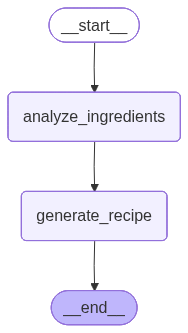

In [7]:
# Visualize the graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

## Part 6 — Running the Agent

Time to test! Enter ingredients and type of diet and watch the agent work through its steps.

After it runs, we can inspect the **full state** — not just the final recipe, but also the intermediate ingredient analysis. This transparency is one of the key advantages of LangGraph over a single LLM call.

In [8]:
# Get user input
ingredients = input("Whats in your Kitchen? ")
type_of_diet = input("What diet do you prefer? ")

# Run the graph
result = app.invoke({"ingredients": ingredients, "type_of_diet": type_of_diet})

# Show the results step by step
print("=" * 60)
print("INGREDIENT ANALYSIS")
print("=" * 60)
print(f"Best known for: {', '.join(result['analysis'].best_known_for)}")
print(f"Cooking times: {', '.join(result['analysis'].cooking_time)}")
print(f"Taste profile: {', '.join(result['analysis'].taste)}")
print(f"Diet type: {', '.join(result['analysis'].type_of_diet)}")

print("\n" + "=" * 60)
print("GENERATED RECIPE")
print("=" * 60)
print(result["recipe"])


INGREDIENT ANALYSIS
Best known for: Pasta dishes, Cheesy flavors, Herbal aromas
Cooking times: 30-40 minutes, 45-60 minutes, 20-30 minutes, 40-50 minutes, 20-30 minutes
Taste profile: Savory, Rich, Citrusy
Diet type: Italian, Western, Comfort

GENERATED RECIPE
**Lemon Chicken Fettuccine with Garlic Potatoes**

 Servings: 4

**Cooking Time:** 40-50 minutes

**Description:** A rich and savory dish featuring chicken, fettuccine pasta, and a burst of citrusy flavor from lemon, all perfectly balanced with garlic potatoes.

**Ingredients:**

- 1 pound boneless, skinless chicken breast or thighs, cut into bite-sized pieces
- 1 cup fettuccine pasta
- 2 tablespoons olive oil
- 2 cloves garlic, minced
- 1 cup grated mozzarella cheese
- 1/2 cup grated parmesan cheese
- 2 tablespoons freshly squeezed lemon juice
- 1 teaspoon dried thyme
- 1/2 teaspoon paprika
- Salt and pepper, to taste
- 2 large potatoes, peeled and thinly sliced
- Fresh parsley, chopped (optional)

**Instructions:**

1. **Prepar